**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
  - 1.1. [Load Dataset](#toc1_1_)    
  - 1.2. [Load kết quả:](#toc1_2_)    
- 2. [Prompting Configuration](#toc2_)    
- 3. [Đánh giá](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Setup](#toc0_)

In [1]:
# import torch

# print(torch.__version__)
# print(torch.version.cuda)

# if torch.cuda.is_available():
#     print(torch.cuda.get_device_name(0))

# # !nvidia-smi

In [2]:
# # Kiểm tra root_dir trên Kaggle
# import os
# print(os.listdir("/kaggle/input/datasets/nostagiguideus17"))


# # Thiết lập để import source code
# import sys
# sys.path.append("/kaggle/input/datasets/nostagiguideus17/abstractive-summary-vers-transformer")

# # Cài đặt thêm lib cần thiết
# !pip install -q evaluate --no-deps
# !pip install -q bert_score --no-deps

# input_path = "/kaggle/input/datasets/nostagiguideus17/abstractive-summary-vers-transformer"
# result_path = "/kaggle/input/datasets/nostagiguideus17/summary-prediction"

input_path = "."
result_path = "."

## 1.1. <a id='toc1_1_'></a>[Load Dataset](#toc0_)

In [3]:
import pandas as pd
from datasets import Dataset

dataset = Dataset.from_parquet(input_path + '/data/train-00000-of-00001.parquet')
train_df = dataset.to_pandas()

dataset = Dataset.from_parquet(input_path + '/data/valid-00000-of-00001.parquet')
valid_df = dataset.to_pandas()

dataset = Dataset.from_parquet(input_path + '/data/test-00000-of-00001.parquet')
test_df = dataset.to_pandas()

data = {
    'test' : test_df,
    'valid' : valid_df,
    'train' : train_df
}

test_df.head()

,article,summary
0,Văn phòng mới của MayTrip tại địa chỉ 833 Lê H...,MayTrip khai trương văn phòng mới tại TP. HCM ...
1,"Đầu tháng 11, dã quỳ bung nở trên các vạt núi ...",Rừng hoa dã quỳ ở Vườn quốc gia Ba Vì rộng kho...
2,"Mùa thu đông năm nay, Tam Cốc đặc biệt và hấp ...","Mùa thu đông năm nay, Tam Cốc đặc biệt và hấp ..."
3,"Cầm cốc chocolate đen nóng trên tay, nữ du khá...",Du khách Anh Monisha Rajesh bắt đầu hành trình...
4,"Cồn Én nằm giữa sông Tiền, thuộc xã Tấn Mỹ, rộ...",Cồn Én là một điểm đến du lịch nằm giữa sông T...


## 1.2. <a id='toc1_2_'></a>[Load kết quả:](#toc0_)

Ở đây ta có thể sử dụng mô hình dự đoán trực tiếp, hoặc load kết quả từ file.

Đầu vào gồm:
- predictions: [List, pd.Series] văn bản dự đoán (bản do mô hình viết)
- references:  [List, pd.Series] văn bản đối chiếu (bản tóm tắt chuẩn của dataset)
- original:    [List, pd.Series] văn bản gốc chưa tóm tắt -> Để nếu cần khi đánh giá bằng LLM (đang code)

In [4]:
import pandas as pd
from datasets import Dataset

# dataset = Dataset.from_parquet(input_path + '/data/partial_results.parquet')
# valid_df = dataset.to_pandas()

# train_df = pd.read_csv("./results/optimus_ViT_small_Runner/results_train_set.csv")
# valid_df = pd.read_csv("./results/optimus_ViT_small_Runner/results_valid_set.csv")
test_df = pd.read_csv("./results/optimus_ViT_small_Runner/results_test_set.csv")

data = {
    'test' : test_df,
    # 'valid' : valid_df,
    # 'train' : train_df
}

valid_df.head()

,article,summary
0,Giải thưởng công bố gần đây bởi World Travel A...,InterContinental Phu Quoc Long Beach Resort đã...
1,Theo bảng xếp hạng 20 quốc gia tốt nhất thế gi...,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ..."
3,Giải thưởng do Tạp chí du lịch Condé Nast Trav...,"Phú Quốc, đảo ngọc của Việt Nam, đã được vinh ..."
4,KKday Vietnam vừa công bố hợp tác chiến lược S...,KKday Vietnam vừa công bố hợp tác chiến lược v...


In [5]:
test_df.iloc[310:320]

,article,reference,prediction
310,Thành Lộc là một trong 28 gương mặt nhận huy c...,Thành Lộc và sân khấu Thiên Đăng đã giành được...,<pad> Thành Lộc là một trong 28 gương mặt nhận...
311,Tác giả cho biết dành 10 năm để chụp con người...,Nhiếp ảnh gia Nguyễn Thanh Tuấn dành 10 năm để...,<pad> Tác giả Nguyễn Thanh Tuấn đã dành 10 năm...
312,"TheoDaily Mail, bà Robin Fleming - chủ tịch ki...",Vụ tranh quyền sở hữu cuộc thi Miss America đa...,"<pad> Một cuộc thi Miss America 2025, người bị..."
313,Tác phẩm do Nhà hát Ca múa nhạc Thăng Long sản...,"Vở kịch ""Giấc mơ Chí Phèo"" được sản xuất bởi N...","<pad> Tác phẩm ""Giấc mơ Chí Phèo"" do Nhà hát C..."
314,Bà Nguyễn Thị Mỹ tổ chức không gian trưng bày ...,Họa sĩ Nguyễn Thị Mỹ vừa tổ chức triển lã cá n...,<pad> Họa sĩ Bùi Thạc Chuyên và vợ Tú Oanh đã ...
315,Tác phẩm do Thủy Nguyễn và êkíp sáng tạo trong...,"Tác phẩm ""Drops of the Sun - Mảnh trời"" của Th...",<pad> Thủy Nguyễn và êkíp sáng tạo trong hai n...
316,"Theo đại diện ban tổ chức, một trong những yếu...","Sự kiện ""Lớp học đáp vui"" của Jollibee thu hút...",<pad> Sự kiện Jollibee thiết lập khu vui chơi ...
317,"Ông Nguyễn Đức Sơn, Hiệu trưởng trường Đại học...",Ngày 20/11 là dịp để tri ân những người thầy c...,<pad> Hiệu trưởng trường Đại học Sư phạm Hà Nộ...
318,Nội dung được nêu trong dự thảo nghị quyết về ...,Dự thảo nghị quyết của HĐND tỉnh Quảng Nam hỗ ...,<pad> Sở Nội dung được nêu trong dự thảo nghị ...
319,Sở Giáo dục và Đào tạo TP HCM ngày 21/11 đưa r...,"Dịp hè, giáo viên TP HCM được giao các nhiệm v...",<pad> Sở Giáo dục và Đào tạo TP HCM vừa đưa ra...


# 2. <a id='toc2_'></a>[Prompting Configuration](#toc0_)

In [6]:
# Prompt là một pattern sở hữu đủ 3 tham số: original, reference, prediction
# Response_key phải khớp với format (JSON) được trả về.


RESPONSE_KEY = ['comment']

PROMPT = """
You are an expert evaluator assessing the quality of a generated summarization. 
Your task is to evaluate the [SUMMARIZATION] based on two criteria: Faithfulness (against the [ORIGINAL]) and Directness (against the [REFERENCE]).

CRITERIA DEFINITIONS:
1. FAITHFUL: Every factual claim in the summarization is true, accurate, and supported by the [ORIGINAL] article.
   - A claim is unfaithful if it adds unsupported facts, modifies numbers/entities, or distorts the original meaning.
2. DIRECT: The summarization concisely captures the key points without introducing noisy, trivial, or irrelevant information.
   - A claim is not direct if it includes minor details not present in the [REFERENCE] or misses the core focus prioritized by the reference.

EVALUATION STEPS (Perform these mentally before outputting):
1. Claim Extraction: Enumerate every factual claim in the [SUMMARIZATION] (numbers, entities, comparisons, etc.).
2. Faithfulness Check (vs. ORIGINAL): Verify if each claim is fully supported by the [ORIGINAL]. If unsupported or contradictory, the summary has factual errors.
3. Directness Check (vs. REFERENCE): Compare the scope of the [SUMMARIZATION] to the [REFERENCE]. Identify if it misses key points or adds unnecessary fluff.
4. Abstraction: Synthesize your findings into a strictly concise abstractive phrase of NO MORE THAN TWO WORDS that describes the overall quality or primary flaw of the summarization.
   - Valid examples: "lesser detail", "wrong events", "greater phrasing", "hallucinated facts", "highly direct", "missing core", "irrelevant fluff", "perfectly faithful".

OUTPUT FORMAT:
Return strictly a valid JSON object. The value for "comment" MUST be a LIST of phrases (each contains 2 consecutive words), separated by a comma. Do not output any markdown formatting (like ```json) or explanation outside the JSON.

{{
    "comment" : "<1-2 word abstractive evaluation>"
}}
    
INPUT DATA:
    
[ORIGINAL]
{original}
    
[REFERENCE]
{reference}
    
[SUMMARIZATION]
{prediction}
"""

In [7]:
# Config: Chỉ cần bắt đầu với `llm` thì sẽ chuyển prompt cho llm đánh giá.

evaluation_config = {
    "rouge": {
        "rouge_types": ["rouge1", "rouge2", "rouge3", "rougeL", "rougeLsum"],
        "use_stemmer": True
    },
    "bertscore": {
        "model_type": "bert-base-multilingual-cased",
        # "num_layers": 24,
        "verbose": True, # BẬT thanh tiến trình cho BERTScore
        "lang": "vi",
        "use_fast_tokenizer": True
    },
    # "llm": {
    #     # --- Nếu dùng OLLAMA ( localhost ) ---
    #     "provider": "ollama", 
    #     "model_name": "qwen2.5:3b",
        
    #     # --- Nếu dùng GROQ ---
    #     # "provider": "groq",
    #     # "model_name": "llama-3.1-8b-instant",
    #     # "api_key": "gsk_xxxxxxx",
        
    #     # --- Nếu dùng LOCAL ---
    #     # "provider": "local",
    #     # "model_name": "Qwen/Qwen2.5-0.5B",


    #     # --- Prompt Engineering ---
    #     "prompt" : PROMPT,
    #     "response_key" : RESPONSE_KEY
    # }
}

# 3. <a id='toc3_'></a>[Đánh giá](#toc0_)

In [8]:
from src.evaluate import MultiEvaluator

evaluator = MultiEvaluator(evaluation_config)

[Info] Đang tải các mô hình đánh giá. Việc này có thể mất chút thời gian...
[Info] Đã tải xong metric: rouge
[Info] Đã tải xong metric: bertscore


In [ ]:
import pandas as pd

for key in data.keys() :
    df = data[key]

    results : pd.DataFrame = evaluator.score_batch(
        references=df['reference'],
        predictions=df['prediction'], 
        originals=df['article']
    )

    # results.to_csv("kaggle/working/results.csv")
    results.to_csv(f"./results/optimus_ViT_small_Runner/evaluation_{key}_set.csv")

KeyError: 'ref'

In [ ]:
df.iloc[1267:1270]

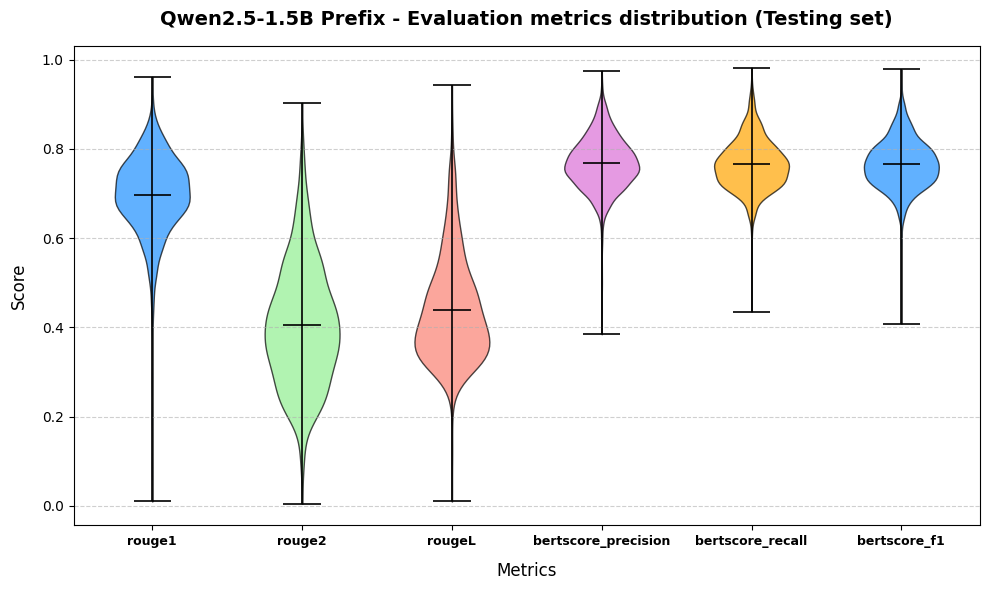

: 

In [ ]:
from src.visualize import visualizeViolinModel, summarizeModel, visualizeWordCloud
import pandas as pd

key = 'valid'

results = pd.read_csv(f"./results/prefix/evaluation_{key}_set.csv")

# print(summarizeModel(
#     results,
#     model_name="Transformer"
# ))

# visualizeWordCloud(
#     results['llm_comment']
# )

visualizeViolinModel(
    results, 
    metrics = ['rouge1', 'rouge2', 'rougeL', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1'],
    plt_name= "Qwen2.5-1.5B Prefix - Evaluation metrics distribution (Testing set)"
)

# visualizeViolinModel(
#     results, 
#     metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1']
# )